# SpaceInvaders DQN y PPO



## 1. Instalación Colab

In [3]:
!pip install -q "stable-baselines3[extra]" "gymnasium[atari]" "ale-py"

In [1]:
import os, time
import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym
import ale_py
import torch

from stable_baselines3 import DQN, PPO
from stable_baselines3.common.env_util import make_atari_env
from stable_baselines3.common.vec_env import VecFrameStack
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.common.callbacks import EvalCallback
from stable_baselines3.common.utils import get_linear_fn

gym.register_envs(ale_py)

ENV_ID = "ALE/SpaceInvaders-v5"
TOTAL_TIMESTEPS = 1_000_000

for d in ["logs_dqn", "logs_ppo"]:
    os.makedirs(d, exist_ok=True)

print("CUDA:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("  device:", torch.cuda.get_device_name(0))
    print("  VRAM total:", round(torch.cuda.get_device_properties(0).total_memory / 1e9, 1), "GB")

CUDA: True
  device: Tesla T4
  VRAM total: 15.6 GB


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## 2. Baseline aleatorio

Antes de entrenar, lanzamos 5 episodios con acciones aleatorias para tener un baseline dl reward

In [2]:
rand_env = make_atari_env(ENV_ID, n_envs=1)
rand_env = VecFrameStack(rand_env, n_stack=4)

rewards = []
for ep in range(5):
    obs = rand_env.reset()
    ep_r, done = 0.0, [False]
    while not done[0]:
        action = [rand_env.action_space.sample()]
        obs, r, done, _ = rand_env.step(action)
        ep_r += r[0]
    rewards.append(ep_r)

print(f"Baseline aleatorio {np.mean(rewards):.1f} +- {np.std(rewards):.1f}")
rand_env.close()

Baseline aleatorio 4.8 +- 4.1


## 3. DQN

Hiperparámetros del Zoo dqn.yml y atari. Replay buffer 100k target net cada 1000 pasos, exploración baja a 0.01 al 10% del entrenamiento.

In [5]:
env = make_atari_env(ENV_ID, n_envs=8, monitor_dir="logs_dqn")
env = VecFrameStack(env, n_stack=4)
eval_env = make_atari_env(ENV_ID, n_envs=1, seed=1234)
eval_env = VecFrameStack(eval_env, n_stack=4)

model_dqn = DQN(
    "CnnPolicy", env, verbose=1, seed=42,
    learning_rate=1e-4,
    buffer_size=100_000,
    learning_starts=100_000,
    batch_size=32,
    gamma=0.99,
    target_update_interval=1000,
    train_freq=4,
    gradient_steps=1,
    exploration_fraction=0.1,
    exploration_final_eps=0.01,
    optimize_memory_usage=True,
    replay_buffer_kwargs={"handle_timeout_termination": False},
    tensorboard_log="logs_dqn/tb",
)

eval_cb_dqn = EvalCallback(
    eval_env, best_model_save_path="logs_dqn/best",
    log_path="logs_dqn/eval", eval_freq=10_000,
    n_eval_episodes=5, deterministic=True, verbose=0,
)

t0 = time.time()
model_dqn.learn(total_timesteps=TOTAL_TIMESTEPS, callback=eval_cb_dqn, progress_bar=True)
print(f"DQN entrenamiento {(time.time()-t0)/60:.1f} min")
model_dqn.save("logs_dqn/dqn_spaceinvaders")
env.close(); eval_env.close()

 100% ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸ 999,960/1,000,000  [ 1:06:57 < 0:00:01 , 244 it/s ]

----------------------------------
| rollout/            |          |
|    ep_len_mean      | 671      |
|    ep_rew_mean      | 297      |
|    exploration_rate | 0.01     |
| time/               |          |
|    episodes         | 19460    |
|    fps              | 248      |
|    time_elapsed     | 4018     |
|    total_timesteps  | 999992   |
| train/              |          |
|    learning_rate    | 0.0001   |
|    loss             | 0.186    |
|    n_updates        | 28124    |
----------------------------------


DQN entrenamiento 67.0 min


## 4. PPO

Hiperparámetros del Zoo, 8 envs paralelos, n_steps=128, batch=256, schedule lineal de lr y clip_range.

In [6]:
env = make_atari_env(ENV_ID, n_envs=8, monitor_dir="logs_ppo")
env = VecFrameStack(env, n_stack=4)
eval_env = make_atari_env(ENV_ID, n_envs=1, seed=1234)
eval_env = VecFrameStack(eval_env, n_stack=4)

model_ppo = PPO(
    "CnnPolicy", env, verbose=1, seed=42,
    learning_rate=get_linear_fn(2.5e-4, 0.0, 1.0),
    n_steps=128,
    batch_size=256,
    n_epochs=4,
    clip_range=get_linear_fn(0.1, 0.0, 1.0),
    vf_coef=0.5,
    ent_coef=0.01,
    tensorboard_log="logs_ppo/tb",
)

eval_cb_ppo = EvalCallback(
    eval_env, best_model_save_path="logs_ppo/best",
    log_path="logs_ppo/eval", eval_freq=10_000,
    n_eval_episodes=5, deterministic=True, verbose=0,
)

t0 = time.time()
model_ppo.learn(total_timesteps=TOTAL_TIMESTEPS, callback=eval_cb_ppo, progress_bar=True)
print(f"PPO entrenamiento: {(time.time()-t0)/60:.1f} min")
model_ppo.save("logs_ppo/ppo_spaceinvaders")
env.close(); eval_env.close()

 100% ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1,000,448/1,000,000  [ 1:07:44 < 0:00:00 , 260 it/s ]

PPO entrenamiento: 67.8 min


## 5. Evaluación

In [ ]:
import pandas as pd

modelos = [
    ("DQN", DQN, "logs_dqn/dqn_spaceinvaders"),
    ("PPO", PPO, "logs_ppo/ppo_spaceinvaders"),
]

filas = []
for nombre, clase, ruta in modelos:
    eval_env = make_atari_env(ENV_ID, n_envs=1, seed=999)
    eval_env = VecFrameStack(eval_env, n_stack=4)
    modelo = clase.load(ruta)
    m, s = evaluate_policy(modelo, eval_env, n_eval_episodes=20, deterministic=True)
    filas.append({"algoritmo": nombre, "reward": round(m, 1), "std": round(s, 1)})
    eval_env.close()

tabla = pd.DataFrame(filas)
print(tabla.to_string(index=False))
tabla.to_csv("tabla_final.csv", index=False)

## 6. Curvas aprendizaje

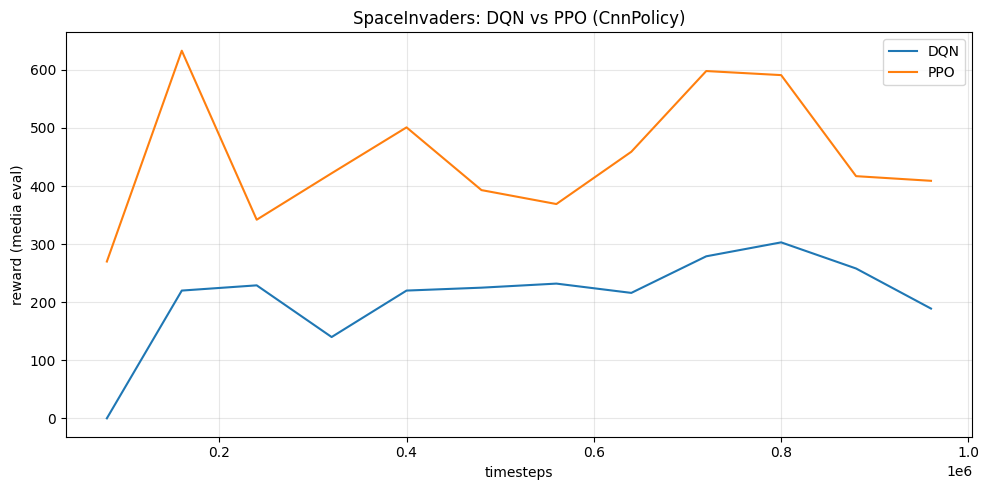

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))
for nombre, log in [("DQN", "logs_dqn"), ("PPO", "logs_ppo")]:
    path = f"{log}/eval/evaluations.npz"
    if not os.path.exists(path):
        print(f"falta {path}")
        continue
    d = np.load(path)
    ax.plot(d["timesteps"], d["results"].mean(axis=1), label=nombre)

ax.set_xlabel("timesteps")
ax.set_ylabel("reward (media eval)")
ax.set_title("SpaceInvaders: DQN vs PPO (CnnPolicy)")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("spaceinvaders_curvas.png", dpi=120)
plt.show()

## 7. Video de un episodio de cada agente entrenado

In [ ]:
from gymnasium.wrappers import RecordVideo

def grabar(nombre, clase, ruta):
    raw_env = gym.make(ENV_ID, render_mode="rgb_array")
    rec_env = RecordVideo(raw_env, video_folder=f"videos_{nombre.lower()}",
                          episode_trigger=lambda i: True, name_prefix=f"{nombre.lower()}_spaceinvaders")
    # Mismo preprocesado que en entrenamiento
    eval_env = make_atari_env(ENV_ID, n_envs=1)
    eval_env = VecFrameStack(eval_env, n_stack=4)
    modelo = clase.load(ruta)
    obs = eval_env.reset()
    raw_obs, _ = rec_env.reset()
    done = [False]
    while not done[0]:
        action, _ = modelo.predict(obs, deterministic=True)
        obs, _, done, _ = eval_env.step(action)
        raw_obs, _, term, trunc, _ = rec_env.step(int(action[0]))
        if term or trunc:
            break
    rec_env.close(); eval_env.close()
    print(f"Video {nombre} guardado en videos_{nombre.lower()}/")

for nombre, clase, ruta in modelos:
    grabar(nombre, clase, ruta)